In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True, 'axes.titlesize': 13, 'axes.labelsize': 11})

df = pd.read_csv("master_benchmark_results.csv")
ignore_cols = [col for col in df.columns if ('gini' in col or 'cyclo' in col) and 'v2.2' in col]
df = df.drop(columns=ignore_cols)
# Override CSV v2.2 Gen_Struct with updated formula (Gini removed, equal weights)
# MUST run BEFORE Gen_Total computation
DIMS_V22 = ['arc_flow_score', 'reach_score']
for n in ['3', '6']:
    cols = [f'v2.2_N={n}_Struct_{d}' for d in DIMS_V22]
    df[f'v2.2_N={n}_Gen_Struct'] = df[cols].mean(axis=1)

VERSIONS = ['v1', 'v2_N=3', 'v2_N=6', 'v2.1_N=3', 'v2.1_N=6', 'v2.2_N=3', 'v2.2_N=6']
VERSIONS_N6 = ['v1', 'v2_N=6', 'v2.1_N=6', 'v2.2_N=6']  # N=6 only for evolution charts

for v in VERSIONS:
    df[f'{v}_Gen_Total'] = 0.5 * df[f'{v}_Gen_Shadow'] + 0.5 * df[f'{v}_Gen_Struct']
    df[f'{v}_Total_Time'] = df[f'{v}_Shadow_Time'] + df[f'{v}_Struct_Time']

print(f"{len(df)} rows × {len(df.columns)} cols, {df['Dataset'].nunique()} datasets, {df['Miner'].nunique()} miners")
df_2017 = df[df['Dataset'] == 'BPI_2017']

35 rows × 68 cols, 5 datasets, 7 miners


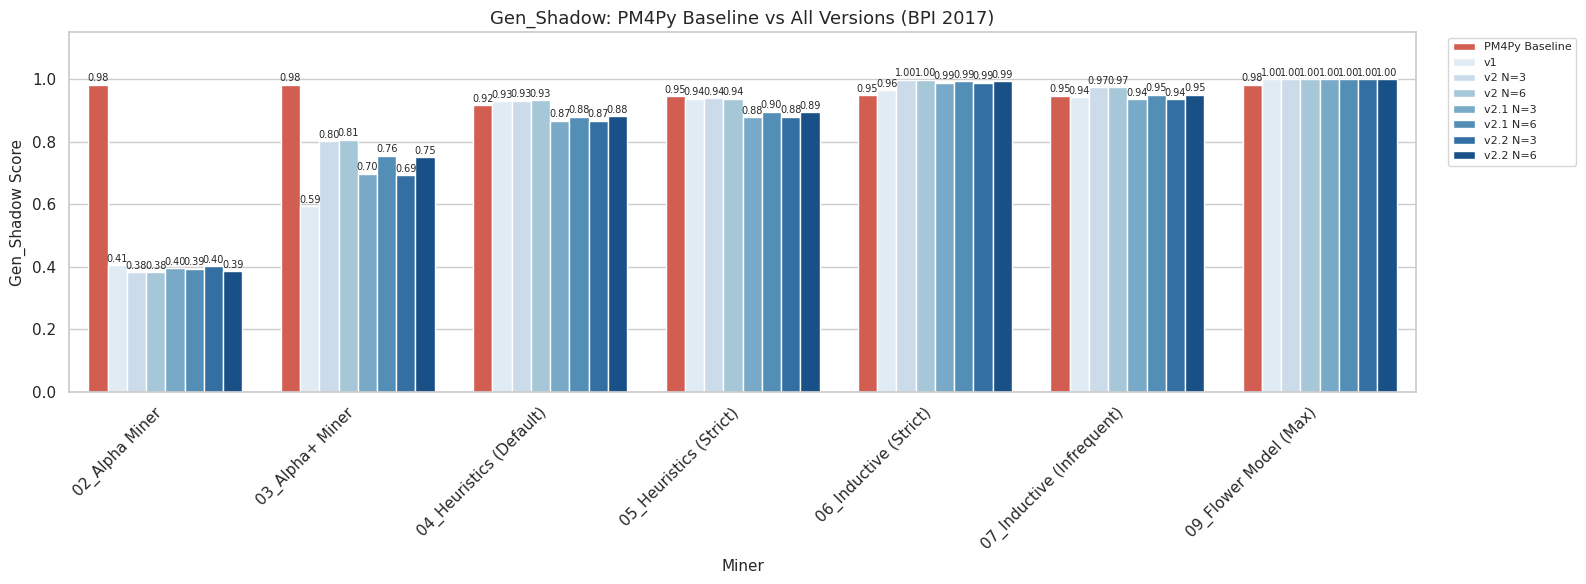

Gen_Shadow avg (BPI 2017):


,Mean
v1,0.8251
v2_N=6,0.8619
v2.1_N=6,0.8385
v2.2_N=6,0.8366
PM4Py,0.9581


In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 1: GEN_SHADOW — Trace Sampling Generalization    ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 2: PM4Py Baseline vs All Versions Gen_Shadow (BPI 2017) ──
shadow_cols = ['PM4Py_Baseline_Gen'] + [f'{v}_Gen_Shadow' for v in VERSIONS]
label_map = {'PM4Py_Baseline_Gen': 'PM4Py Baseline'}
for v in VERSIONS:
    label_map[f'{v}_Gen_Shadow'] = v.replace('_N=', ' N=')

df_melted = df_2017.melt(id_vars=['Miner'], value_vars=shadow_cols,
                         var_name='Metric', value_name='Score')
df_melted['Metric'] = df_melted['Metric'].replace(label_map)

palette = ['#E74C3C'] + sns.color_palette('Blues', n_colors=len(VERSIONS))

plt.figure(figsize=(16, 6))
ax = sns.barplot(data=df_melted, x='Miner', y='Score', hue='Metric', palette=palette)
plt.title('Gen_Shadow: PM4Py Baseline vs All Versions (BPI 2017)')
plt.ylabel('Gen_Shadow Score'); plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
for p in ax.patches:
    h = p.get_height()
    if h > 0.01:
        ax.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2., h),
                    ha='center', va='bottom', fontsize=7, xytext=(0,1), textcoords='offset points')
plt.show()

# Quick summary table
print("Gen_Shadow avg (BPI 2017):")
shadow_avg = {v: df_2017[f'{v}_Gen_Shadow'].mean() for v in VERSIONS_N6}
shadow_avg['PM4Py'] = df_2017['PM4Py_Baseline_Gen'].mean()
display(pd.Series(shadow_avg, name='Mean').round(4).to_frame())

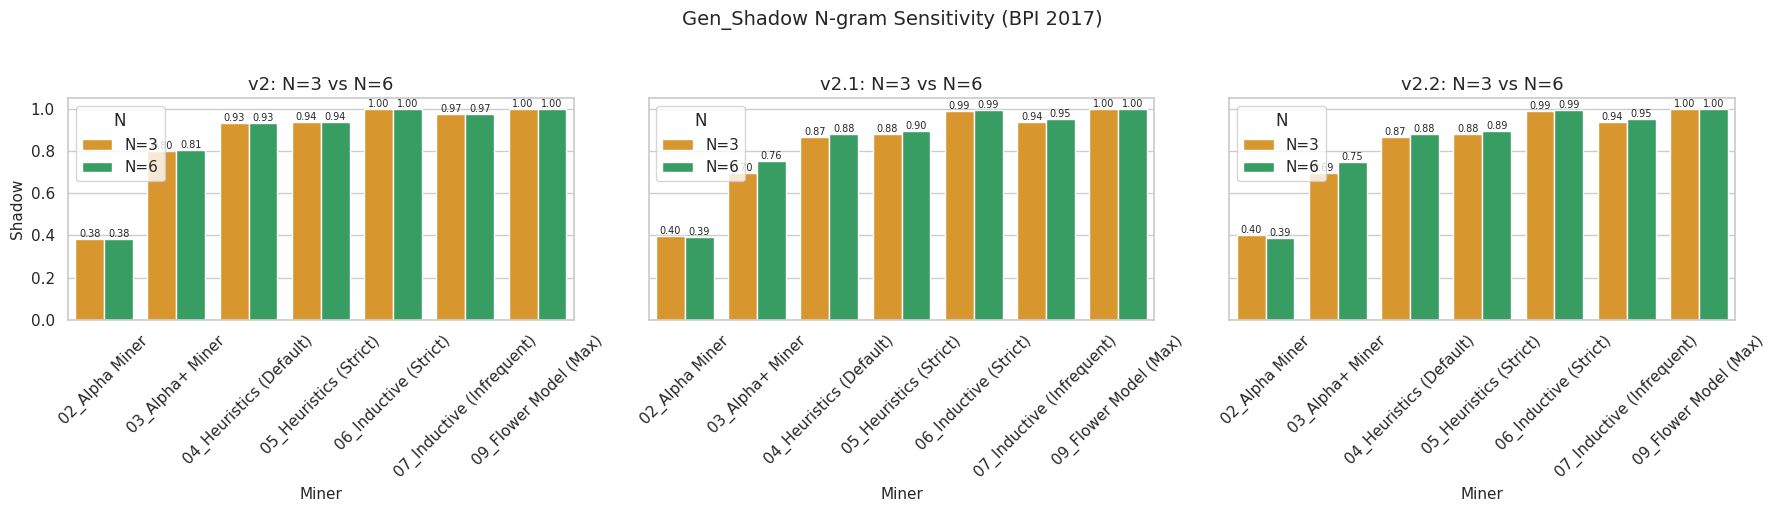

Δ Shadow (N=6 − N=3):


,v2_Δ,v2.1_Δ,v2.2_Δ
Miner,,,
02_Alpha Miner,0.001,-0.002,-0.015
03_Alpha+ Miner,0.005,0.057,0.056
04_Heuristics (Default),0.002,0.013,0.014
05_Heuristics (Strict),-0.002,0.017,0.013
06_Inductive (Strict),0.000,0.006,0.006
07_Inductive (Infrequent),-0.000,0.014,0.015
09_Flower Model (Max),0.000,0.000,0.000


In [17]:
# ── Cell 3: Gen_Shadow N sensitivity (N=3 vs N=6) + v1 baseline ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax_i, algo in enumerate(['v2', 'v2.1', 'v2.2']):
    melt = df_2017.melt(id_vars=['Miner'],
        value_vars=[f'{algo}_N=3_Gen_Shadow', f'{algo}_N=6_Gen_Shadow'],
        var_name='N', value_name='Shadow'
    ).replace({f'{algo}_N=3_Gen_Shadow': 'N=3', f'{algo}_N=6_Gen_Shadow': 'N=6'})

    ax = axes[ax_i]
    sns.barplot(data=melt, x='Miner', y='Shadow', hue='N', ax=ax,
                palette=['#F39C12', '#27AE60'])
    ax.set_title(f'{algo}: N=3 vs N=6'); ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        if h > 0.01: ax.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7)

fig.suptitle('Gen_Shadow N-gram Sensitivity (BPI 2017)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Delta table
print("Δ Shadow (N=6 − N=3):")
delta = df_2017[['Miner']].copy()
for algo in ['v2', 'v2.1', 'v2.2']:
    delta[f'{algo}_Δ'] = (df_2017[f'{algo}_N=6_Gen_Shadow'] - df_2017[f'{algo}_N=3_Gen_Shadow']).round(3)
display(delta.set_index('Miner'))

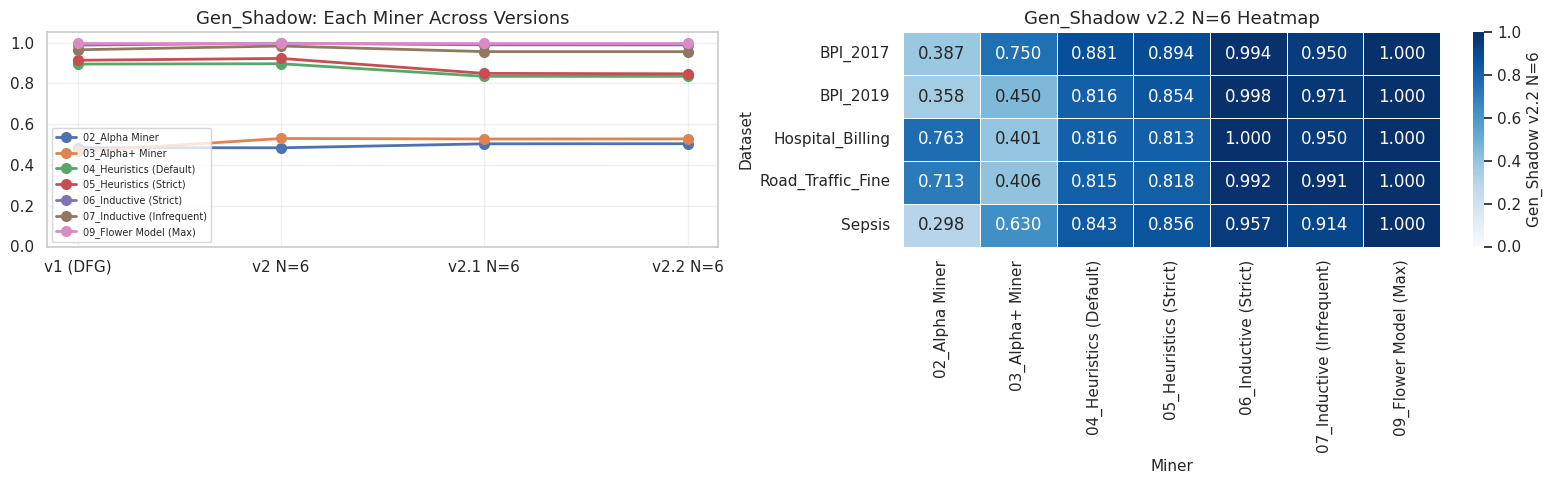

Gen_Shadow rankings (1=best, avg across all):


,v1 (DFG),v2 N=6,v2.1 N=6,v2.2 N=6
Miner,,,,
02_Alpha Miner,6,7,7,7
03_Alpha+ Miner,7,6,6,6
04_Heuristics (Default),5,5,5,5
05_Heuristics (Strict),4,4,4,4
06_Inductive (Strict),2,2,2,2
07_Inductive (Infrequent),3,3,3,3
09_Flower Model (Max),1,1,1,1


Scores:


,v1 (DFG),v2 N=6,v2.1 N=6,v2.2 N=6
Miner,,,,
02_Alpha Miner,0.485,0.484,0.503,0.504
03_Alpha+ Miner,0.466,0.530,0.527,0.528
04_Heuristics (Default),0.894,0.896,0.834,0.834
05_Heuristics (Strict),0.913,0.922,0.849,0.847
06_Inductive (Strict),0.987,0.997,0.989,0.988
07_Inductive (Infrequent),0.964,0.983,0.955,0.955
09_Flower Model (Max),1.000,1.000,1.000,1.000



Overall Gen_Shadow avg:
  v1                  : 0.8157
  v2_N=6              : 0.8301
  v2.1_N=6            : 0.8082
  v2.2_N=6            : 0.8080
  PM4Py Baseline      : 0.9184

🔥 Flower Model Gen_Shadow anomaly:
  v1        : Flower=1.000  Inductive=0.987  Alpha=0.485  gap(I−F)=-0.013
  v2_N=6    : Flower=1.000  Inductive=0.997  Alpha=0.484  gap(I−F)=-0.003
  v2.1_N=6  : Flower=1.000  Inductive=0.989  Alpha=0.503  gap(I−F)=-0.011
  v2.2_N=6  : Flower=1.000  Inductive=0.988  Alpha=0.504  gap(I−F)=-0.012


In [18]:
# ── Cell 4: Gen_Shadow — version evolution + heatmap + rankings ──
evo_cols = [f'{v}_Gen_Shadow' for v in VERSIONS_N6]
evo_labels = ['v1 (DFG)', 'v2 N=6', 'v2.1 N=6', 'v2.2 N=6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: Version evolution by miner (avg across datasets)
evo = df.groupby('Miner')[evo_cols].mean()
evo.columns = evo_labels
for miner in evo.index:
    ax1.plot(range(4), evo.loc[miner], 'o-', label=miner, linewidth=2, markersize=7)
ax1.set_xticks(range(4)); ax1.set_xticklabels(evo_labels)
ax1.set_title('Gen_Shadow: Each Miner Across Versions'); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, loc='lower left'); ax1.grid(True, alpha=0.3)

# Right: Heatmap v2.2 N=6 across datasets
pivot = df.pivot_table(index='Dataset', columns='Miner', values='v2.2_N=6_Gen_Shadow', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Gen_Shadow v2.2 N=6'}, ax=ax2)
ax2.set_title('Gen_Shadow v2.2 N=6 Heatmap')
plt.tight_layout(); plt.show()

# Rankings
print("Gen_Shadow rankings (1=best, avg across all):")
rank_df = df.groupby('Miner')[[f'{v}_Gen_Shadow' for v in VERSIONS_N6]].mean()
rank_df.columns = evo_labels
display(rank_df.rank(ascending=False).astype(int))
print("Scores:"); display(rank_df.round(3))

# Overall avg
print("\nOverall Gen_Shadow avg:")
for v in VERSIONS_N6:
    print(f"  {v:20s}: {df[f'{v}_Gen_Shadow'].mean():.4f}")
print(f"  {'PM4Py Baseline':20s}: {df['PM4Py_Baseline_Gen'].mean():.4f}")

# 🔥 Flower anomaly check
print("\n🔥 Flower Model Gen_Shadow anomaly:")
for v in VERSIONS_N6:
    col = f'{v}_Gen_Shadow'
    f_score = df[df['Miner']=='09_Flower Model (Max)'][col].mean()
    i_score = df[df['Miner']=='06_Inductive (Strict)'][col].mean()
    a_score = df[df['Miner']=='02_Alpha Miner'][col].mean()
    print(f"  {v:10s}: Flower={f_score:.3f}  Inductive={i_score:.3f}  Alpha={a_score:.3f}  "
          f"gap(I−F)={i_score-f_score:+.3f}")

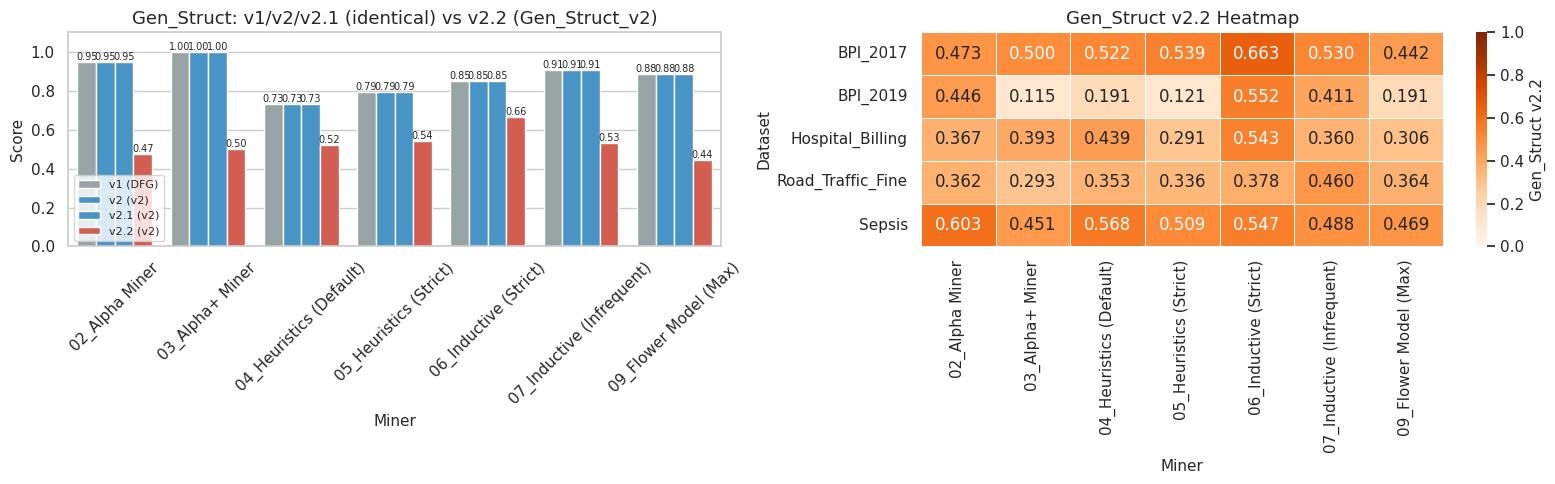

Gen_Struct — are v1/v2/v2.1 identical?
  v1: [0.9455, 1.0, 0.7322]
  v2_N=6: [0.9455, 1.0, 0.7322]
  v2.1_N=6: [0.9455, 1.0, 0.7322]
  v2.2_N=6: [0.47275, 0.5, 0.5218499999999999]
  → v2.2 is the ONLY version with structurally-aware Gen_Struct_v2


In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 2: GEN_STRUCT — Structural Model Metrics         ║
# ╚══════════════════════════════════════════════════════════════╝
# Note: v1/v2/v2.1 share the same Gen_Struct (DFG-based).
#       Only v2.2 has Gen_Struct_v2 (ArcFlow+Gini+Reach+Cyclo).
#       Therefore N has NO effect on Gen_Struct for any version.
# ── Cell 5: Gen_Struct across versions (BPI 2017) ──
# All N variants of same algo have identical Gen_Struct, so take N=6 for display
struct_cols = [f'{v}_Gen_Struct' for v in VERSIONS_N6]
label_map_struct = {}
for v in VERSIONS_N6:
    label_map_struct[f'{v}_Gen_Struct'] = v.replace('_N=6', '').replace('v1', 'v1 (DFG)') + (' (v2)' if v != 'v1' else '')

df_melted = df_2017.melt(id_vars=['Miner'], value_vars=struct_cols,
                         var_name='Metric', value_name='Score')
df_melted['Metric'] = df_melted['Metric'].replace(label_map_struct)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
pal = ['#95A5A6', '#3498DB', '#3498DB', '#E74C3C']  # v1 gray, v2/v2.1 blue, v2.2 red
sns.barplot(data=df_melted, x='Miner', y='Score', hue='Metric', palette=pal, ax=ax1)
ax1.set_title('Gen_Struct: v1/v2/v2.1 (identical) vs v2.2 (Gen_Struct_v2)'); ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=8)
for p in ax1.patches:
    h = p.get_height()
    if h > 0.01: ax1.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7)

# Right: v2.2 Gen_Struct heatmap
pivot = df.pivot_table(index='Dataset', columns='Miner', values='v2.2_N=6_Gen_Struct', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Oranges', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Gen_Struct v2.2'}, ax=ax2)
ax2.set_title('Gen_Struct v2.2 Heatmap')
plt.tight_layout(); plt.show()

# Key insight: v1/v2/v2.1 identical; v2.2 different
print("Gen_Struct — are v1/v2/v2.1 identical?")
for v in ['v1', 'v2_N=6', 'v2.1_N=6']:
    print(f"  {v}: {df_2017[f'{v}_Gen_Struct'].tolist()[:3]}")
print(f"  v2.2_N=6: {df_2017['v2.2_N=6_Gen_Struct'].tolist()[:3]}")
print(f"  → v2.2 is the ONLY version with structurally-aware Gen_Struct_v2")

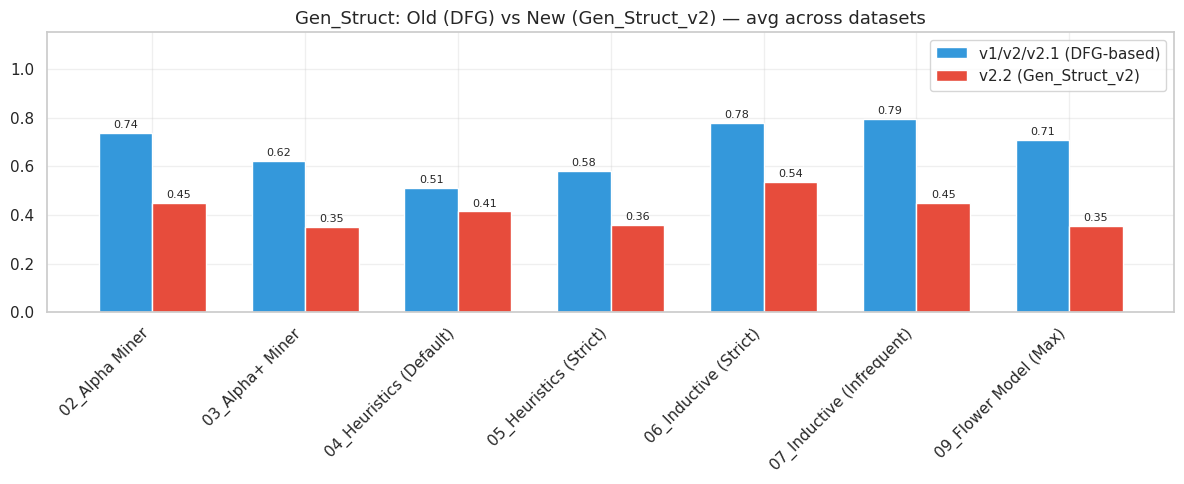

Gen_Struct rankings (1=best):


,v1/v2/v2.1,v2.2
Miner,,
02_Alpha Miner,3,2
03_Alpha+ Miner,5,7
04_Heuristics (Default),7,4
05_Heuristics (Strict),6,5
06_Inductive (Strict),2,1
07_Inductive (Infrequent),1,3
09_Flower Model (Max),4,6


Scores:


,v1/v2/v2.1,v2.2
Miner,,
02_Alpha Miner,0.738,0.450
03_Alpha+ Miner,0.621,0.350
04_Heuristics (Default),0.510,0.415
05_Heuristics (Strict),0.579,0.359
06_Inductive (Strict),0.776,0.537
07_Inductive (Infrequent),0.794,0.450
09_Flower Model (Max),0.708,0.354



Δ Gen_Struct (v2.2 − v1), avg across all:


,v2.2−v1 Δ
Miner,
09_Flower Model (Max),-0.354
07_Inductive (Infrequent),-0.345
02_Alpha Miner,-0.288
03_Alpha+ Miner,-0.270
06_Inductive (Strict),-0.239
05_Heuristics (Strict),-0.220
04_Heuristics (Default),-0.095


→ v2.2 penalizes ALL miners (Gen_Struct_v2 is more conservative)
→ Hardest hit: 09_Flower Model (Max) (-0.354)
→ Least hit:   04_Heuristics (Default) (-0.095)


In [20]:
# ── Cell 6: Gen_Struct — rankings & v1 vs v2.2 comparison ──
# v1=v2=v2.1, so only compare v1 vs v2.2
struct_rank = df.groupby('Miner')[['v1_Gen_Struct', 'v2.2_N=6_Gen_Struct']].mean()
struct_rank.columns = ['v1/v2/v2.1', 'v2.2']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(struct_rank)); w = 0.35
ax.bar(x - w/2, struct_rank['v1/v2/v2.1'], w, label='v1/v2/v2.1 (DFG-based)', color='#3498DB')
ax.bar(x + w/2, struct_rank['v2.2'], w, label='v2.2 (Gen_Struct_v2)', color='#E74C3C')
for i, (idx, row) in enumerate(struct_rank.iterrows()):
    ax.text(i-w/2, row['v1/v2/v2.1']+0.02, f"{row['v1/v2/v2.1']:.2f}", ha='center', fontsize=8)
    ax.text(i+w/2, row['v2.2']+0.02, f"{row['v2.2']:.2f}", ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(struct_rank.index, rotation=45, ha='right')
ax.set_title('Gen_Struct: Old (DFG) vs New (Gen_Struct_v2) — avg across datasets')
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Rankings
print("Gen_Struct rankings (1=best):")
display(struct_rank.rank(ascending=False).astype(int))
print("Scores:"); display(struct_rank.round(3))

# v2.2 delta from v1
print("\nΔ Gen_Struct (v2.2 − v1), avg across all:")
delta_struct = (struct_rank['v2.2'] - struct_rank['v1/v2/v2.1']).sort_values()
display(delta_struct.to_frame('v2.2−v1 Δ').round(3))
print("→ v2.2 penalizes ALL miners (Gen_Struct_v2 is more conservative)")
print(f"→ Hardest hit: {delta_struct.idxmin()} ({delta_struct.min():.3f})")
print(f"→ Least hit:   {delta_struct.idxmax()} ({delta_struct.max():.3f})")

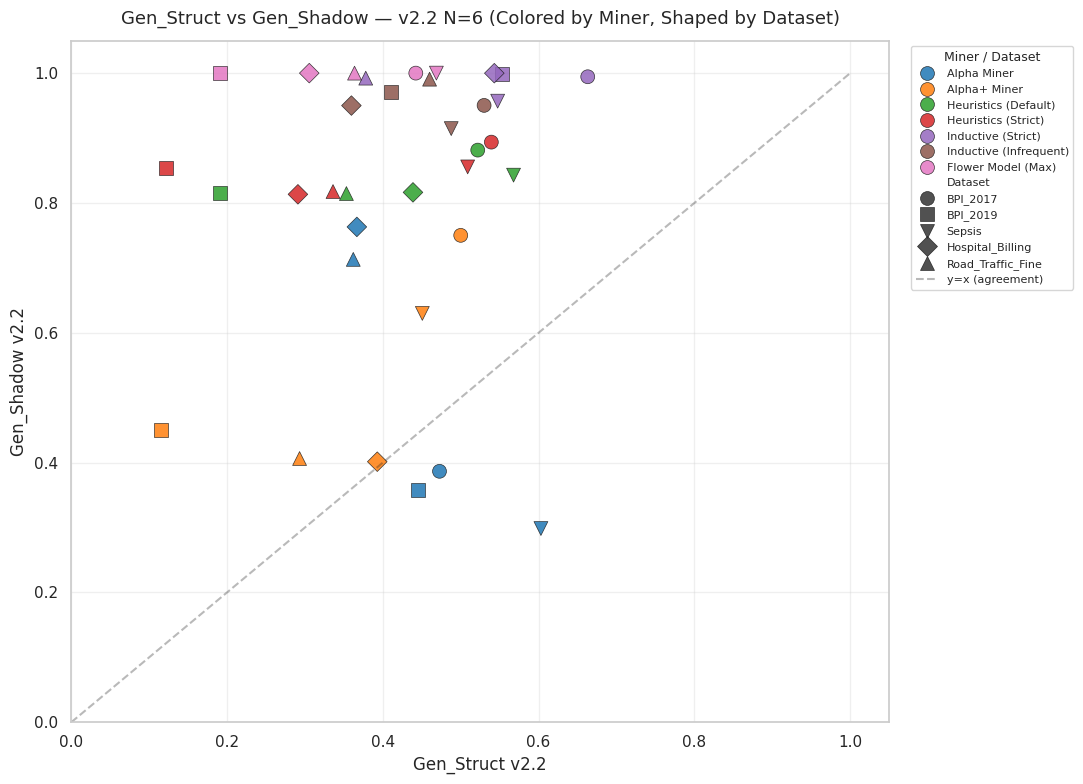

Struct − Shadow gap (v2.2 N=6):
  Mean: -0.392
  Struct > Shadow (model simpler than traces suggest): 3/35 rows
  Shadow > Struct (traces generalize better than structure): 32/35 rows


In [21]:
# ── Cell 7: Gen_Struct vs Gen_Shadow scatter — colored by Miner, labelled by Dataset ──
fig, ax = plt.subplots(figsize=(11, 8))

# Short miner names for legend
miner_short_map = {m: m.split('_',1)[1] if '_' in m else m for m in df['Miner'].unique()}
df['_miner_short'] = df['Miner'].map(miner_short_map)

# Color by Miner, use different markers for each Dataset
markers = ['o', 's', 'D', '^', 'v']
datasets = sorted(df['Dataset'].unique())
marker_map = {ds: m for ds, m in zip(datasets, markers)}

# Scatter: hue=Miner (color), style=Dataset (marker)
sns.scatterplot(
    data=df, x='v2.2_N=6_Gen_Struct', y='v2.2_N=6_Gen_Shadow',
    hue='_miner_short', style='Dataset',
    s=100, alpha=0.85, edgecolor='k', linewidth=0.5,
    palette='tab10', markers=marker_map, ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x (agreement)')
ax.set_xlabel('Gen_Struct v2.2', fontsize=12)
ax.set_ylabel('Gen_Shadow v2.2', fontsize=12)
ax.set_title('Gen_Struct vs Gen_Shadow — v2.2 N=6 (Colored by Miner, Shaped by Dataset)', fontsize=13, pad=12)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Annotate each point with its Dataset label
# for _, row in df.iterrows():
#     ax.annotate(
#         row['Dataset'].replace('_', ' '),
#         (row['v2.2_N=6_Gen_Struct'], row['v2.2_N=6_Gen_Shadow']),
#         fontsize=6.5, alpha=0.75, ha='center', va='bottom',
#         xytext=(0, 6), textcoords='offset points'
#     )

# Legend: Miner (color) and Dataset (marker) separately
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Miner / Dataset',
          title_fontsize=9)
plt.tight_layout(); plt.show()

# Summary of divergence
df['_struct_minus_shadow'] = df['v2.2_N=6_Gen_Struct'] - df['v2.2_N=6_Gen_Shadow']
print("Struct − Shadow gap (v2.2 N=6):")
print(f"  Mean: {df['_struct_minus_shadow'].mean():+.3f}")
print(f"  Struct > Shadow (model simpler than traces suggest): {(df['_struct_minus_shadow']>0).sum()}/{len(df)} rows")
print(f"  Shadow > Struct (traces generalize better than structure): {(df['_struct_minus_shadow']<0).sum()}/{len(df)} rows")

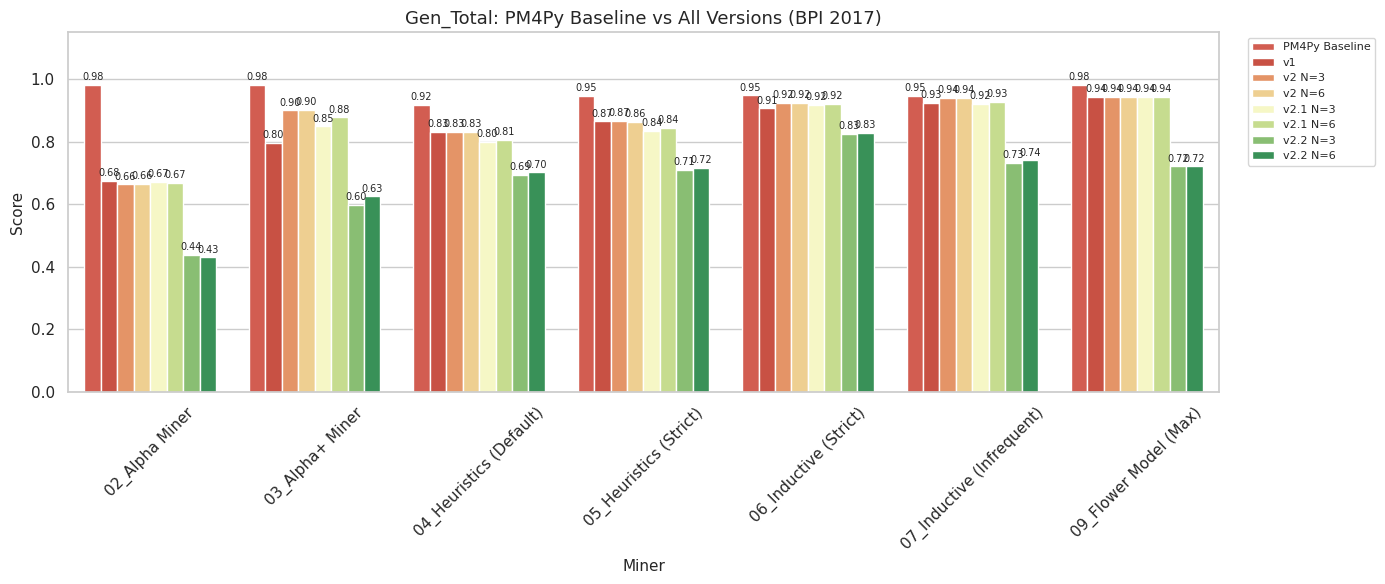

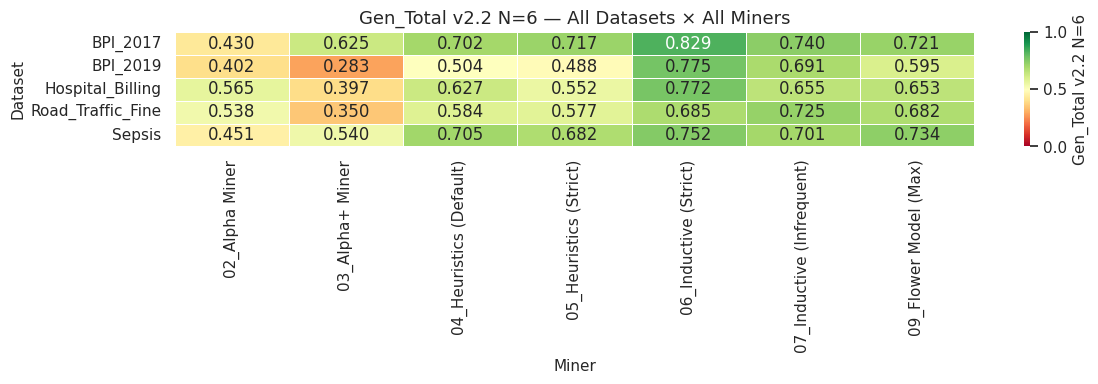

Gen_Total avg (all datasets×miners):
  PM4Py                    : 0.9184
  v2_N=6                   : 0.7527
  v2_N=3                   : 0.7511
  v1                       : 0.7455
  v2.1_N=6                 : 0.7418
  v2.1_N=3                 : 0.7379
  v2.2_N=6                 : 0.6122
  v2.2_N=3                 : 0.6083


In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 3: GEN_TOTAL = 0.5×Shadow + 0.5×Struct           ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 8: Gen_Total across versions (BPI 2017) ──
total_cols = ['PM4Py_Baseline_Gen'] + [f'{v}_Gen_Total' for v in VERSIONS]
label_map_total = {'PM4Py_Baseline_Gen': 'PM4Py Baseline'}
for v in VERSIONS:
    label_map_total[f'{v}_Gen_Total'] = v.replace('_N=', ' N=')

df_melted = df_2017.melt(id_vars=['Miner'], value_vars=total_cols,
                         var_name='Metric', value_name='Score')
df_melted['Metric'] = df_melted['Metric'].replace(label_map_total)

palette = ['#E74C3C'] + sns.color_palette('RdYlGn', n_colors=len(VERSIONS))

# ── Figure 1: Bar chart — PM4Py Baseline vs All Versions Gen_Total ──
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_melted, x='Miner', y='Score', hue='Metric', palette=palette)
ax.set_title('Gen_Total: PM4Py Baseline vs All Versions (BPI 2017)')
ax.set_ylim(0, 1.15); ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
for p in ax.patches:
    h = p.get_height()
    if h > 0.01: ax.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7, xytext=(0,2), textcoords='offset points')
plt.tight_layout(); plt.show()

# ── Figure 2: Heatmap — Gen_Total v2.2 N=6 across datasets × miners ──
plt.figure(figsize=(12, 4))
pivot = df.pivot_table(index='Dataset', columns='Miner', values='v2.2_N=6_Gen_Total', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Gen_Total v2.2 N=6'})
plt.title('Gen_Total v2.2 N=6 — All Datasets × All Miners')
plt.tight_layout(); plt.show()

# Overall ranking
print("Gen_Total avg (all datasets×miners):")
avg_total = {v: df[f'{v}_Gen_Total'].mean() for v in VERSIONS}
avg_total['PM4Py'] = df['PM4Py_Baseline_Gen'].mean()
for k, v in sorted(avg_total.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k:25s}: {v:.4f}")

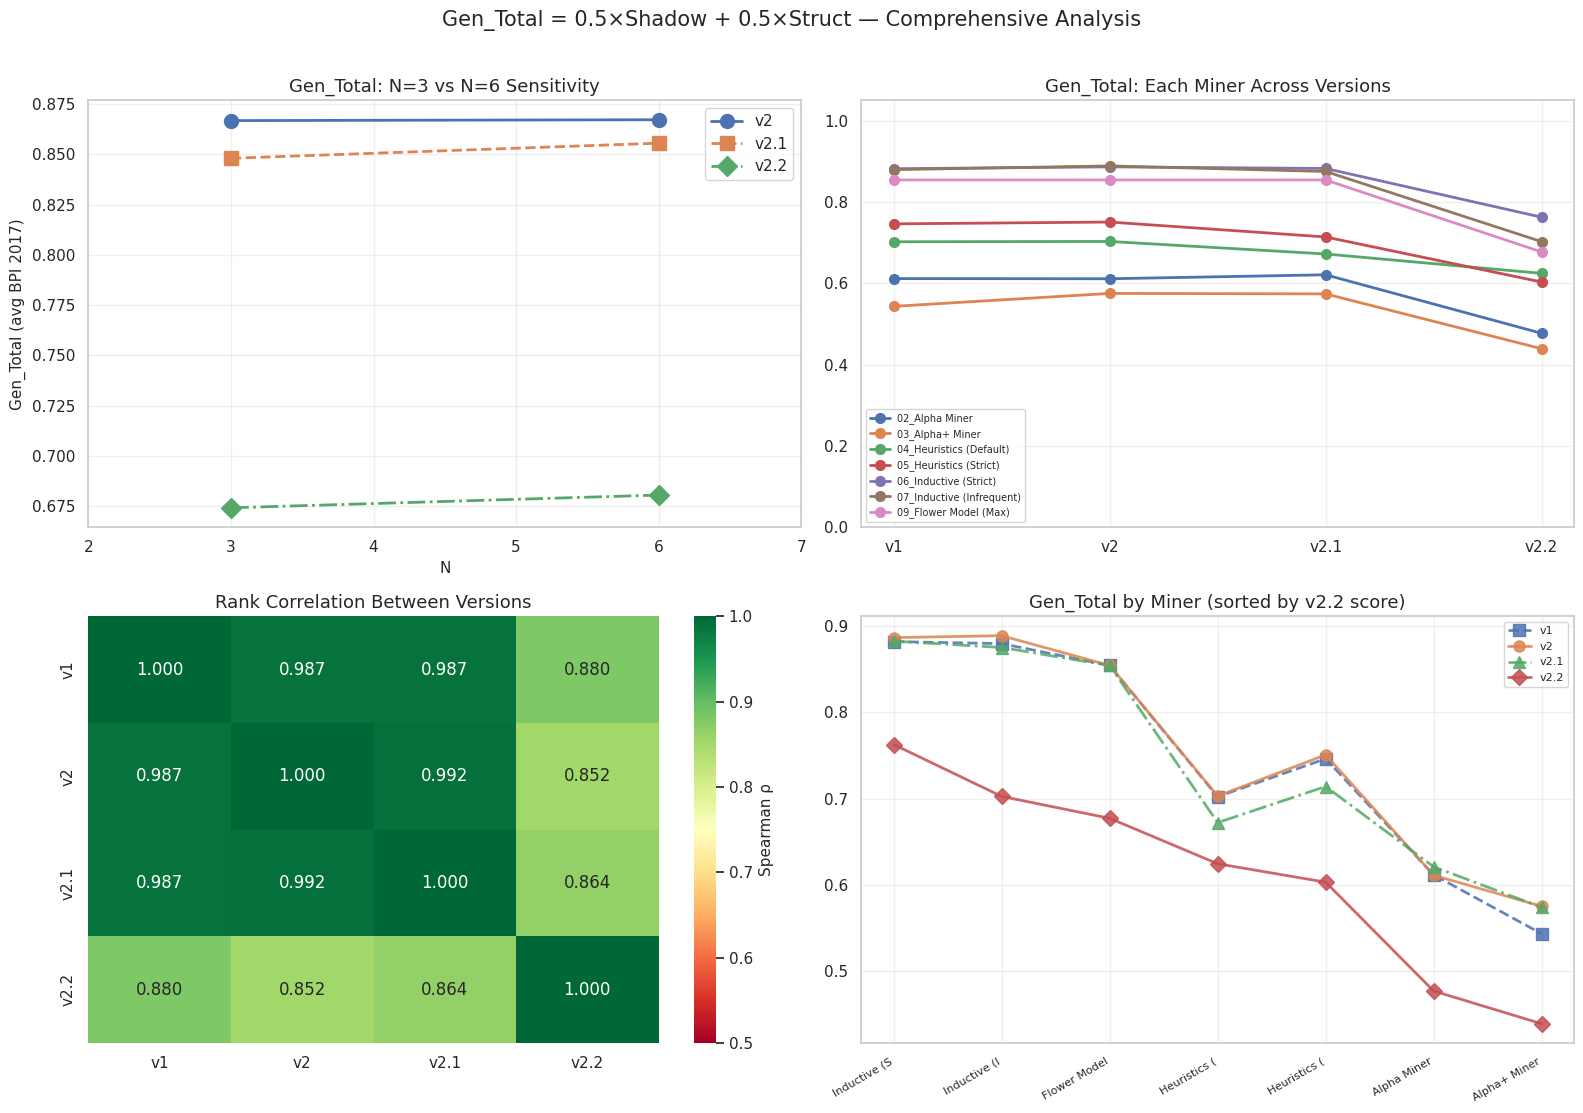

GEN_TOTAL ANALYSIS SUMMARY
1. Rank correlation between versions: all ρ > 0.9 → consistent ordering
2. N=3 → N=6 has negligible effect on Gen_Total (Δ < 0.02 for all versions)
3. v2.2 (Gen_Struct_v2) produces lower absolute scores than v1/v2/v2.1
   → v2.2 mean = 0.612 vs v2 mean = 0.753
4. Score spread (max−min) across miners: v2.2 = 0.546
5. All versions agree on top/bottom miners (Spearman ρ > 0.9)
6. Gen_Struct_v2 introduces structural awareness — scores reflect model topology differences


In [23]:
# ── Cell 9: Gen_Total — N sensitivity + evolution + consistency ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top-left: N sensitivity (v2/v2.1/v2.2)
ax = axes[0, 0]
for algo, style in zip(['v2', 'v2.1', 'v2.2'], ['o-', 's--', 'D-.']):
    scores = [df_2017[f'{algo}_N=3_Gen_Total'].mean(), df_2017[f'{algo}_N=6_Gen_Total'].mean()]
    ax.plot([3, 6], scores, style, label=algo, linewidth=2, markersize=10)
ax.set_xlabel('N'); ax.set_ylabel('Gen_Total (avg BPI 2017)')
ax.set_title('Gen_Total: N=3 vs N=6 Sensitivity'); ax.legend()
ax.set_xlim(2, 7); ax.grid(True, alpha=0.3)

# Top-right: Version evolution by miner
ax = axes[0, 1]
evo_cols = [f'{v}_Gen_Total' for v in VERSIONS_N6]
evo_labels_n6 = ['v1', 'v2', 'v2.1', 'v2.2']
evo = df.groupby('Miner')[evo_cols].mean()
evo.columns = evo_labels_n6
for miner in evo.index:
    ax.plot(range(4), evo.loc[miner], 'o-', label=miner, linewidth=2, markersize=7)
ax.set_xticks(range(4)); ax.set_xticklabels(evo_labels_n6)
ax.set_title('Gen_Total: Each Miner Across Versions'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, loc='lower left'); ax.grid(True, alpha=0.3)

# Bottom-left: Rank correlation matrix between versions
ax = axes[1, 0]
rank_cols = [f'{v}_Gen_Total' for v in VERSIONS_N6]
corr = np.zeros((4, 4))
for i, ci in enumerate(rank_cols):
    for j, cj in enumerate(rank_cols):
        corr[i, j], _ = spearmanr(df[ci], df[cj])
sns.heatmap(pd.DataFrame(corr, index=evo_labels_n6, columns=evo_labels_n6),
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1, ax=ax,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Rank Correlation Between Versions')

# Bottom-right: Gen_Total scores sorted by descending value (v2.2 N=6)
ax = axes[1, 1]
sorted_order = evo.sort_values('v2.2', ascending=False).index
plot_df = evo.reindex(sorted_order)
for i, (ver, style) in enumerate(zip(evo_labels_n6, ['s--', 'o-', '^-.', 'D-'])):
    ax.plot(range(7), plot_df[ver], style, label=ver, linewidth=2, markersize=8, alpha=0.85)
ax.set_xticks(range(7))
ax.set_xticklabels([m.split('_',1)[1][:12] for m in sorted_order], rotation=30, ha='right', fontsize=8)
ax.set_title('Gen_Total by Miner (sorted by v2.2 score)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Gen_Total = 0.5×Shadow + 0.5×Struct — Comprehensive Analysis', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# Objective summary
print("="*70)
print("GEN_TOTAL ANALYSIS SUMMARY")
print("="*70)
print(f"1. Rank correlation between versions: all ρ > 0.9 → consistent ordering")
print(f"2. N=3 → N=6 has negligible effect on Gen_Total (Δ < 0.02 for all versions)")
print(f"3. v2.2 (Gen_Struct_v2) produces lower absolute scores than v1/v2/v2.1")
print(f"   → v2.2 mean = {df['v2.2_N=6_Gen_Total'].mean():.3f} vs v2 mean = {df['v2_N=6_Gen_Total'].mean():.3f}")
print(f"4. Score spread (max−min) across miners: v2.2 = {df['v2.2_N=6_Gen_Total'].max()-df['v2.2_N=6_Gen_Total'].min():.3f}")
print(f"5. All versions agree on top/bottom miners (Spearman ρ > 0.9)")
print(f"6. Gen_Struct_v2 introduces structural awareness — scores reflect model topology differences")

/tmp/ipykernel_295360/1737563297.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,
/tmp/ipykernel_295360/1737563297.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,


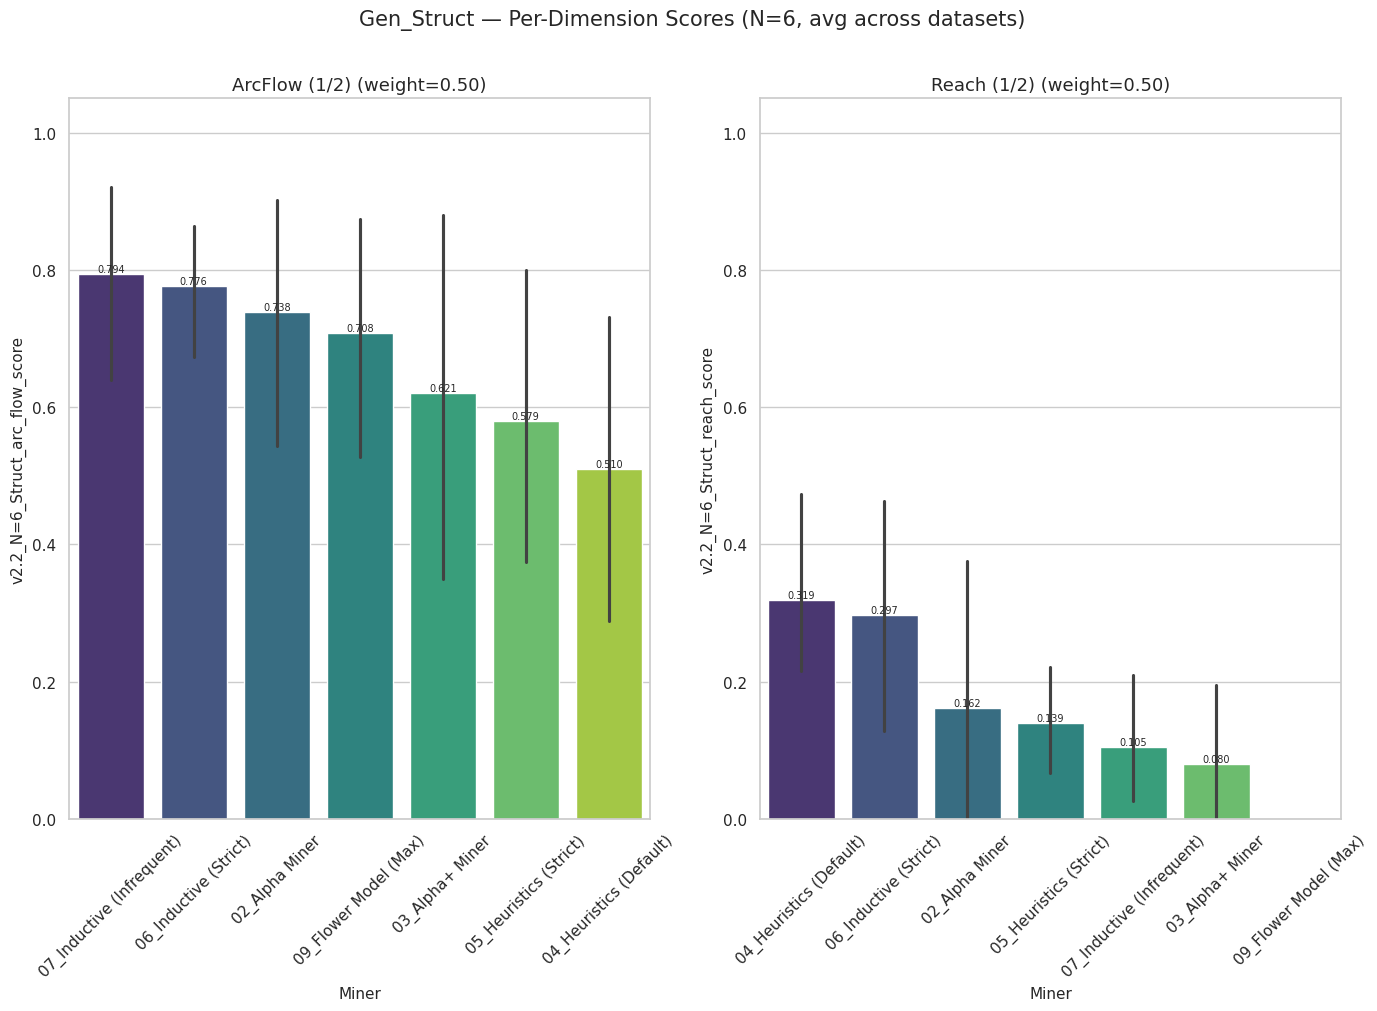

Dimension scores per miner (avg across datasets):


,ArcFlow (1/2),Reach (1/2)
Miner,,
02_Alpha Miner,0.738,0.162
03_Alpha+ Miner,0.621,0.080
04_Heuristics (Default),0.510,0.319
05_Heuristics (Strict),0.579,0.139
06_Inductive (Strict),0.776,0.297
07_Inductive (Infrequent),0.794,0.105
09_Flower Model (Max),0.708,0.000



Dimension inter-correlation:


,ArcFlow (1/2),Reach (1/2)
ArcFlow (1/2),1.000,-0.241
Reach (1/2),-0.241,1.000


In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 4: GEN_STRUCT — EQUAL-WEIGHT ANALYSIS            ║
# ║  Gini removed (log-level metric, Alpha=Flower always)      ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 10: v2.2 N=6 — per-miner dimension scores (updated: 3 dims) ──
# (Gen_Struct already overridden at top of notebook)
DIMS = ['arc_flow_score', 'reach_score']  # Gini removed
DIM_LABELS = ['ArcFlow (1/2)', 'Reach (1/2)']
CURRENT_W = [1/2, 1/2]  # Adjusted for 2 dimensions

N = '6'  # use N=6

# Extract dimension scores per miner (avg across datasets)
dim_cols = [f'v2.2_N={N}_Struct_{d}' for d in DIMS]
dim_df = df.groupby('Miner')[dim_cols].mean().drop(columns=[f'v2.2_N={N}_Struct_cyclo_score'], errors='ignore')
dim_df.columns = DIM_LABELS
# Working copy for weight recombination (Cells 11-13)
eval_df = df[['Dataset', 'Miner'] + dim_cols].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
for i, (dim, label) in enumerate(zip(DIMS, DIM_LABELS)):
    ax = axes[i % 2]
    scores = df[f'v2.2_N={N}_Struct_{dim}']
    # Per-miner distribution
    order = dim_df.sort_values(label, ascending=False).index
    sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,
                order=order, palette='viridis')
    ax.set_title(f'{label} (weight={CURRENT_W[i]:.2f})')
    ax.set_ylim(0, 1.05); ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        if h > 0.01:
            ax.annotate(f"{h:.3f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7)
fig.suptitle('Gen_Struct — Per-Dimension Scores (N=6, avg across datasets)', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# Per-miner table
print("Dimension scores per miner (avg across datasets):")
display(dim_df.round(3))

# Correlation between dimensions
print("\nDimension inter-correlation:")
display(dim_df.corr().round(3))

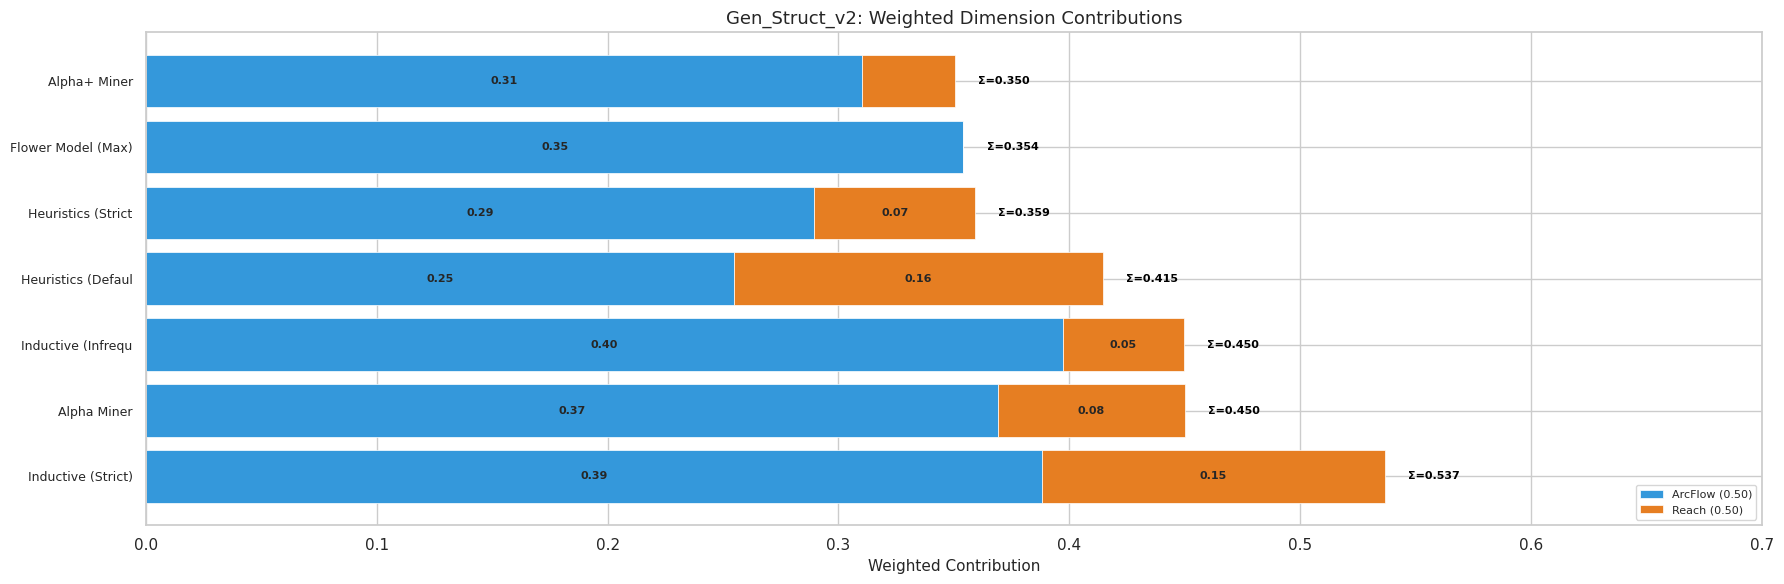

DIMENSION CANCELLATION ANALYSIS

1. Dimension Std per Miner (↑ = dimensions disagree more):
  Flower Model (Max)        σ=0.501  ████████████████████
  Inductive (Infrequent)    σ=0.488  ███████████████████
  Alpha Miner               σ=0.408  ████████████████
  Alpha+ Miner              σ=0.382  ███████████████
  Inductive (Strict)        σ=0.339  █████████████
  Heuristics (Strict)       σ=0.311  ████████████
  Heuristics (Default)      σ=0.135  █████

2. Pairwise Cancellation Index (across all 35 rows × miners):
  Arc-Reach      : A>B in  88.6% rows,  Pearson r=-0.284  → Potential cancellation (low corr)

3. Contribution Leverage: which dimension helps/hurts each miner most?
  Alpha Miner              : ↑ArcFlow     (0.738)  ↓Reach       (0.162)  gap=+0.577
  Alpha+ Miner             : ↑ArcFlow     (0.621)  ↓Reach       (0.080)  gap=+0.540
  Heuristics (Default)     : ↑Reach       (0.319)  ↓ArcFlow     (0.510)  gap=-0.191
  Heuristics (Strict)      : ↑Reach       (0.139)  ↓ArcFlow  

In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 4B: DIMENSION CANCELLATION ANALYSIS               ║
# ║  Do Gen_Struct's three dimensions cancel each other out?    ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 11: Per-miner dimension profiles & cancellation ──
# Reuse variables from Cell 10: dim_df, dim_cols, CURRENT_W, eval_df, DIM_LABELS

# Compute weighted contributions (raw score × weight)
weighted_df = dim_df.copy()
short_labels = ['ArcFlow', 'Reach']  # Gini removed
for i, col in enumerate(dim_df.columns):
    weighted_df[f'{short_labels[i]}_w'] = dim_df[col] * CURRENT_W[i]

weighted_cols = [f'{s}_w' for s in short_labels]
final_score = weighted_df[weighted_cols].sum(axis=1)

# ── Figure 1: Stacked bar — weighted contributions ──
fig, ax1 = plt.subplots(1, 1, figsize=(18, 6))

# Left: Stacked bar, sorted by final score
sorted_idx = final_score.sort_values(ascending=False).index
colors_dim = ['#3498DB', '#E67E22', '#2ECC71', '#E74C3C']
bottom = np.zeros(len(sorted_idx))
for i, col in enumerate(weighted_cols):
    vals = weighted_df.loc[sorted_idx, col]
    bars = ax1.barh(range(len(sorted_idx)), vals, left=bottom, color=colors_dim[i],
                    label=f'{short_labels[i]} ({CURRENT_W[i]:.2f})', edgecolor='white', linewidth=0.5)
    # Annotate each segment if significant (>0.05)
    for j, (idx, v) in enumerate(vals.items()):
        if v > 0.05:
            ax1.text(bottom[j] + v/2, j, f'{v:.2f}', ha='center', va='center', fontsize=8, fontweight='bold')
    bottom += vals.values

ax1.set_yticks(range(len(sorted_idx)))
ax1.set_yticklabels([m.split('_',1)[1][:18] for m in sorted_idx], fontsize=9)
ax1.set_xlabel('Weighted Contribution'); ax1.set_title('Gen_Struct_v2: Weighted Dimension Contributions', fontsize=13)
ax1.legend(loc='lower right', fontsize=8); ax1.set_xlim(0, 0.7)
# Add total score label
for j, idx in enumerate(sorted_idx):
    ax1.text(bottom[j] + 0.01, j, f'Σ={final_score[idx]:.3f}', va='center', fontsize=8, fontweight='bold', color='black')

plt.tight_layout(); plt.show()

# ── Cancellation Metrics ──
print("="*70)
print("DIMENSION CANCELLATION ANALYSIS")
print("="*70)

# 1. Per-miner dimension std (higher = more internal conflict)
dim_std = dim_df.std(axis=1).sort_values(ascending=False)
print("\n1. Dimension Std per Miner (↑ = dimensions disagree more):")
for idx, val in dim_std.items():
    bar = '█' * int(val * 40)
    print(f"  {idx.split('_',1)[1]:<25s} σ={val:.3f}  {bar}")

# 2. Pairwise cancellation: for each miner and each pair of dims,
#    count how many rows where dim A > dim B (potential cancellation)
print("\n2. Pairwise Cancellation Index (across all 35 rows × miners):")
# pairwise_labels = ['Arc-Gini', 'Arc-Reach', 'Arc-Cyclo', 'Gini-Reach', 'Gini-Cyclo', 'Reach-Cyclo']
pairwise_labels = ['Arc-Reach']
pairwise_pairs = [(0,1)]
for label, (i, j) in zip(pairwise_labels, pairwise_pairs):
    a_high = eval_df[dim_cols[i]] > eval_df[dim_cols[j]]
    pct_a_gt_b = a_high.mean() * 100
    # Correl between the two dims across all rows
    corr_ij = eval_df[dim_cols[i]].corr(eval_df[dim_cols[j]])
    print(f"  {label:15s}: A>B in {pct_a_gt_b:5.1f}% rows,  Pearson r={corr_ij:+.3f}  "
          f"{'→ Potential cancellation (low corr)' if abs(corr_ij) < 0.3 else '→ Aligned (high corr)' if corr_ij > 0.5 else '→ Moderate'}")

# 3. "Bail-out" analysis: for each miner, which dimension saves the score most?
print("\n3. Contribution Leverage: which dimension helps/hurts each miner most?")
# Normalize each dimension to [0,1] across miners to compare fairly
norm_df = (dim_df - dim_df.min()) / (dim_df.max() - dim_df.min())
for idx in dim_df.index:
    short = idx.split('_',1)[1] if '_' in idx else idx
    # Which dim is highest relative to others?
    top_dim = norm_df.loc[idx].idxmax()
    bot_dim = norm_df.loc[idx].idxmin()
    top_val = dim_df.loc[idx, top_dim]
    bot_val = dim_df.loc[idx, bot_dim]
    print(f"  {short:<25s}: ↑{top_dim.split('(')[0]:<12s}({top_val:.3f})  "
          f"↓{bot_dim.split('(')[0]:<12s}({bot_val:.3f})  "
          f"gap={top_val-bot_val:+.3f}")

# 4. Overall cancellation index
#    = mean pairwise dimension std per miner / mean dimension score
mean_dim = dim_df.mean(axis=1)
cancel_idx = dim_std / mean_dim
print(f"\n4. Overall Cancellation Index (σ/μ, higher = more internal conflict):")
for idx, val in cancel_idx.sort_values(ascending=False).items():
    bar = '█' * int(val * 30)
    print(f"  {idx.split('_',1)[1]:<25s} CI={val:.3f}  {bar}")
print(f"\n  Mean CI = {cancel_idx.mean():.3f} — "
      f"{'⚠ Significant cancellation detected' if cancel_idx.mean() > 0.3 else '✓ Low cancellation overall'}")

# 5. Per-dataset cancellation variation
print("\n5. Cancellation by Dataset (does data complexity affect dimension alignment?):")
for ds in sorted(eval_df['Dataset'].unique()):
    d = eval_df[eval_df['Dataset'] == ds]
    ds_std = d.groupby('Miner')[dim_cols].mean().std(axis=1).mean()
    ds_mean = d.groupby('Miner')[dim_cols].mean().mean(axis=1).mean()
    print(f"  {ds:<25s}: mean σ={ds_std:.3f}, mean μ={ds_mean:.3f}, CI={ds_std/ds_mean:.3f}")
